# Aprendizado Supervisionado e Classificação Bayesiana

--- 

### Resumo dos Conceitos Fundamentais

### O que é Aprendizado Supervisionado?

O aprendizado supervisionado (*Supervised Learning*) é um tipo de Machine Learning em que o modelo aprende a partir de exemplos rotulados.

O objetivo é construir uma função capaz de mapear entradas (`X`) em saídas (`y`).


**Formulação Matemática**

Buscamos uma função:

$$
y = f(X) + \epsilon
$$

Onde:

- $X$ = variáveis independentes (*features*)
- $y$ = variável alvo (*target*)
- $f(X)$ = modelo aprendido
- $\epsilon$ = erro ou ruído


*Intuição*

O modelo tenta aprender padrões nos dados para conseguir prever corretamente novos exemplos nunca vistos.


### Tipos de Problemas

**Regressão**

A saída é um valor contínuo.

Exemplos:

- preço de imóveis
- temperatura
- previsão de vendas

```python
Preço da casa = 500000
```


**Classificação**

A saída pertence a categorias discretas.

Exemplos:

- spam / não spam
- fraude / não fraude
- gato / cachorro

```python
Classe = "Spam"
```


#### Os Três Ingredientes do Machine Learning

Todo modelo supervisionado possui três componentes principais.


*1. Dados ($D$)*

Os dados consistem em:

- matriz de atributos ($X$)
- vetor de rótulos ($y$)

*2. Modelo ($f$)*

Uma função parametrizada por $\theta$.

Exemplo:

$$
f(X;\theta)
$$

O objetivo do treinamento é encontrar os melhores parâmetros.

*3. Função de Custo ($C$)*

Mede o erro do modelo.

Exemplo clássico:

##### Erro Quadrático Médio (MSE)

$$
MSE =
\frac{1}{n}
\sum_{i=1}^{n}
(y_i - \hat{y}_i)^2
$$


*Intuição*

A função de custo responde:

> "Quão ruim está minha previsão?"

O treinamento busca minimizar essa função.

--- 
### Generalização vs. Overfitting

*Generalização*

O verdadeiro aprendizado acontece quando o modelo consegue performar bem em dados novos.


*Overfitting (Sobreajuste)*

Ocorre quando o modelo:

- memoriza os dados de treino
- aprende ruídos
- perde capacidade de generalização


Exemplo intuitivo

Imagine um polinômio extremamente complexo tentando passar exatamente por todos os pontos.

- Ele pode acertar perfeitamente o treino, mas errar novos dados.

*Sinais de Overfitting*

| Treino | Teste |
|---|---|
| erro baixo | erro alto |


*Intuição importante*

```text
Bom modelo:
aprende padrões

Modelo overfit:
memoriza ruído
```
---

# Classificação

Vamos inicialmente ler os dados:

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive
np.random.seed(10)

drive.mount('/content/drive/')
data = pd.read_csv('/content/drive/My Drive/dados/Vehicle.csv', header=(0))

print("Número de linhas e colunas:", data.shape)
data.head(10)

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).
Número de linhas e colunas: (846, 19)


,Comp,Circ,D.Circ,Rad.Ra,Pr.Axis.Ra,Max.L.Ra,Scat.Ra,Elong,Pr.Axis.Rect,Max.L.Rect,Sc.Var.Maxis,Sc.Var.maxis,Ra.Gyr,Skew.Maxis,Skew.maxis,Kurt.maxis,Kurt.Maxis,Holl.Ra,Class
0,95,48,83,178,72,10,162,42,20,159,176,379,184,70,6,16,187,197,van
1,91,41,84,141,57,9,149,45,19,143,170,330,158,72,9,14,189,199,van
2,104,50,106,209,66,10,207,32,23,158,223,635,220,73,14,9,188,196,saab
3,93,41,82,159,63,9,144,46,19,143,160,309,127,63,6,10,199,207,van
4,85,44,70,205,103,52,149,45,19,144,241,325,188,127,9,11,180,183,bus
5,107,57,106,172,50,6,255,26,28,169,280,957,264,85,5,9,181,183,bus
6,97,43,73,173,65,6,153,42,19,143,176,361,172,66,13,1,200,204,bus
7,90,43,66,157,65,9,137,48,18,146,162,281,164,67,3,3,193,202,van
8,86,34,62,140,61,7,122,54,17,127,141,223,112,64,2,14,200,208,van
9,93,44,98,197,62,11,183,36,22,146,202,505,152,64,4,14,195,204,saab


Vamos construir as variáveis $X$ e $y$, sendo que o processo classificação se resume em estimar a função $f$ na relação $y = f(X) + \epsilon$, onde $\epsilon$ é o erro, que tem distribuição normal com média igual a zero e variância $\sigma^2$.

Convertemos os dados para o formato Numpy para facilitar a sua manipulação.

In [17]:
y = data.iloc[:,-1]
classes = np.array(pd.unique(y))
data = data.to_numpy()
nrow,ncol = data.shape
X = data[:,0:ncol-1]

Para treinar o classificador, precisamos definir o conjunto de teste e treinamento.

In [18]:
from sklearn.model_selection import train_test_split
p = 0.7 # fracao de elementos no conjunto de treinamento
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size = p, random_state = 42)

A partir desse conjunto de dados, podemos realizar a classificação.

--- 

## Classificador Bayesiano

 O Classificador de Bayes é um classificador probabilístico baseado no Teorema de Bayes.

A ideia central é:

> escolher a classe com maior probabilidade posterior.

**Regra de Decisão**

Classificamos uma observação $x$ na classe:

$$
C_i =
\arg\max P(C_i | x)
$$


*Intuição*

O modelo pergunta:

> "Dado esse exemplo, qual classe é mais provável?"


**Teorema de Bayes**

$$
P(C_j|x)=
\frac{
p(x|C_j)P(C_j)
}{
p(x)
}
$$


**Componentes do Teorema**

*Probabilidade a priori*

$$
P(C_j)
$$

Representa a frequência da classe antes de observar os dados.

Exemplo:

```python
90% dos emails NÃO são spam
```


*Verossimilhança*

$$
p(x|C_j)
$$

Probabilidade de observar os atributos $x$ dado que a classe é $C_j$.


**Evidência**

$$
p(x)
$$

Fator de normalização.

Garantia de que as probabilidades somem 1.

---

Vamos considerar o caso paramétrico, assumindo que cada variável está distribuída de acordo com uma distribuição Normal. Outras distribuições também podem ser utilizadas.

Já selecionamos os conjuntos de treinamento e teste anteriormente. No conjunto de treinamento, vamos calcular a média e desvio padrão de cada atributo para cada classe. A seguir, reaizamos a classificação, dos dados usando a teoria da decisão Bayesiana, isto é: $X \in C_i$ se, e somente se, $P(C_i|X) = \max P(C_j|X)$ para todo $j$.

In [19]:
from scipy.stats import multivariate_normal

#matrix to store the probabilities
P = pd.DataFrame(data=np.zeros((X_test.shape[0], len(classes))), columns = classes)
Pc = np.zeros(len(classes)) #fraction of elements in each class
for i in np.arange(0, len(classes)):
    elements = np.array(np.where(y_train == classes[i]))
    Pc[i] = elements.shape[1]/len(y_train)
    Z = X_train[elements,:][0].astype(float)
    m = np.mean(Z, axis = 0)
    cv = np.cov(np.transpose(Z))
    for j in np.arange(0,X_test.shape[0]):
        x = X_test[j,:]
        pj = multivariate_normal.pdf(x, mean=m, cov=cv, allow_singular=True)
        P.loc[j,classes[i]] = pj*Pc[i]

In [20]:
print(P)

              van          saab           bus          opel
0    3.151847e-31  9.858817e-33  3.543175e-22  2.008144e-31
1    6.312434e-22  8.955506e-55  3.281194e-42  8.854235e-50
2    9.549453e-27  5.676222e-27  2.992373e-21  5.149165e-27
3    9.547932e-24  1.721556e-22  8.561567e-31  1.066572e-23
4    1.378438e-24  1.437899e-23  1.577016e-19  2.212885e-22
..            ...           ...           ...           ...
249  0.000000e+00  3.956652e-48  1.151983e-24  4.088737e-38
250  9.983964e-41  1.042205e-27  1.593905e-21  1.251171e-26
251  3.347217e-26  9.737831e-25  9.084512e-27  2.271166e-23
252  9.126644e-31  7.769182e-21  8.030936e-30  4.552604e-21
253  2.841329e-20  4.741875e-45  1.377657e-43  4.032846e-40

[254 rows x 4 columns]


Classifica de acordo com a classe mais provável:

In [21]:
y_pred = []
#np.array(test_x.shape[0], dtype=str)
for i in np.arange(0, X_test.shape[0]):
    c = np.argmax(np.array(P.iloc[[i]]))
    y_pred.append(classes[c])
y_pred = np.array(y_pred)
y_test = np.array(y_test)
print(y_pred)

['bus' 'van' 'bus' 'saab' 'bus' 'van' 'van' 'saab' 'bus' 'saab' 'saab'
 'bus' 'van' 'opel' 'opel' 'van' 'saab' 'bus' 'saab' 'opel' 'van' 'van'
 'opel' 'opel' 'opel' 'saab' 'opel' 'van' 'van' 'van' 'opel' 'van' 'bus'
 'van' 'van' 'bus' 'bus' 'saab' 'bus' 'opel' 'van' 'bus' 'opel' 'van'
 'saab' 'saab' 'bus' 'van' 'bus' 'van' 'bus' 'bus' 'van' 'saab' 'bus'
 'opel' 'saab' 'opel' 'saab' 'saab' 'bus' 'van' 'saab' 'bus' 'bus' 'bus'
 'saab' 'saab' 'opel' 'opel' 'saab' 'bus' 'saab' 'bus' 'van' 'van' 'saab'
 'opel' 'saab' 'van' 'bus' 'van' 'saab' 'saab' 'opel' 'saab' 'van' 'bus'
 'van' 'saab' 'saab' 'opel' 'bus' 'bus' 'opel' 'bus' 'van' 'van' 'bus'
 'opel' 'saab' 'saab' 'opel' 'van' 'bus' 'bus' 'saab' 'van' 'saab' 'opel'
 'van' 'bus' 'van' 'bus' 'bus' 'van' 'bus' 'opel' 'bus' 'saab' 'bus'
 'opel' 'saab' 'van' 'bus' 'saab' 'bus' 'van' 'bus' 'saab' 'bus' 'van'
 'bus' 'saab' 'bus' 'bus' 'bus' 'saab' 'opel' 'bus' 'van' 'saab' 'bus'
 'bus' 'van' 'opel' 'saab' 'opel' 'van' 'saab' 'opel' 'bus' 'bus' 's

In [22]:
from sklearn.metrics import accuracy_score
score = accuracy_score(y_pred, y_test)
print('Accuracy:', score)

Accuracy: 0.8937007874015748


## Caso não paramétrico

Para o caso unidimensional, seja $(X_1,X_2, \ldots, X_n)$ uma amostra aleatória unidimensional identicamente distribuída de acordo com alguma função de distribuição $f$ não conhecida. Para estimarmos o formato de $f$, usamos um estimador (kernel density estimator):
\begin{equation}
\widehat{f}_{h}(x)={\frac {1}{n}}\sum _{i=1}^{n}K_{h}(x-x_{i})={\frac {1}{nh}}\sum _{i=1}^{n}K{\Big (}{\frac {x-x_{i}}{h}}{\Big )},
\end{equation}
onde $K$ é a função kernel.
A estimação depende do parâmetro $h$, que é um parâmetro livre e controla a abertura da função.

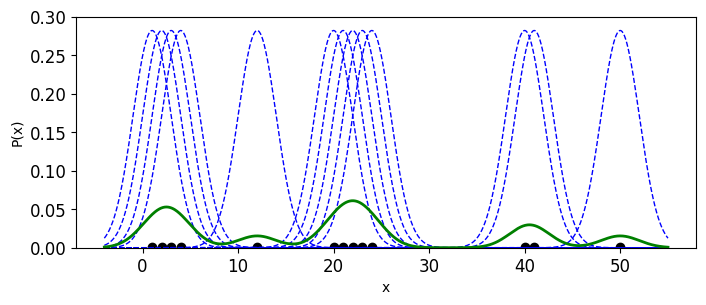

In [48]:
import numpy as np
import matplotlib.pyplot as plt

N = 20
# gera os dados
X = np.array([1, 2, 3, 4, 12, 20,21,22,23,24,40,41, 50])
X = X.reshape((len(X), 1))
# mostra os dados
plt.figure(figsize=(8,3))
plt.plot(X[:, 0], 0.001*np.ones(X.shape[0]), 'ok')

# valores x para serem usados nas densidades
X_plot = np.linspace(np.min(X)-5, np.max(X)+5, 1000)[:, np.newaxis]

h=2
fhat = 0 # estimacao obtida
for x in X:
    # distribuição normal centrada em x
    f = (1/np.sqrt(2*np.pi*h))*np.exp(-((X_plot - x)**2)/(2*h**2))
    fhat = fhat + f # acumula as distribuições
    plt.plot(X_plot,f, '--', color = 'blue', linewidth=1)

# mostra a distribuição estimada
plt.plot(X_plot,fhat/(len(X)*np.sqrt(h)), color = 'green', linewidth=2)
plt.xlabel('x', fontsize = 10)
plt.ylabel('P(x)', fontsize = 10)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.ylim((0, 0.3))
plt.show(True)

Esse resultado pode ser obtido usando-se a função KernelDensity scikit-learn.

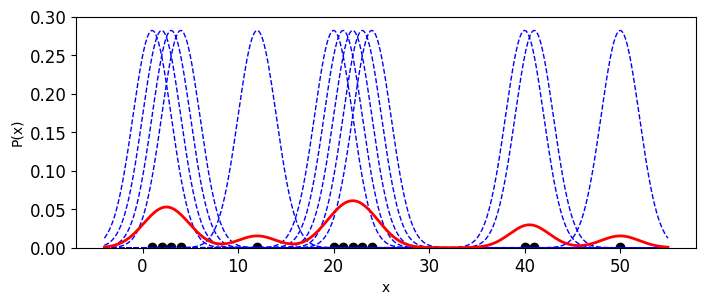

In [50]:
import numpy as np
from matplotlib.pyplot import cm
from sklearn.neighbors import KernelDensity

color=['red', 'blue', 'magenta', 'gray', 'green']

N = 20
X = np.array([1, 2, 3, 4, 12, 20,21,22,23,24,40,41, 50])
X = X.reshape((len(X), 1))

plt.figure(figsize=(8,3))
plt.plot(X[:, 0], 0.001*np.ones(X.shape[0]), 'ok')

X_plot = np.linspace(np.min(X)-5, np.max(X)+5, 1000)[:, np.newaxis]

h=2
fhat = 0
for x in X:
    f = (1/np.sqrt(2*np.pi*h))*np.exp(-((X_plot - x)**2)/(2*h**2))
    plt.plot(X_plot,f, '--', color = 'blue', linewidth=1)

kde = KernelDensity(kernel='gaussian', bandwidth=h).fit(X)
log_dens = np.exp(kde.score_samples(X_plot)) # score_samples() returns the log density.
plt.plot(X_plot,log_dens, color = 'red', linewidth=2, label = 'h='+str(h))
plt.xlabel('x', fontsize = 10)
plt.ylabel('P(x)', fontsize = 10)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.ylim((0, 0.3))

plt.show(True)

Notem que o formato da estimação depende do parâmetro livre $h$.

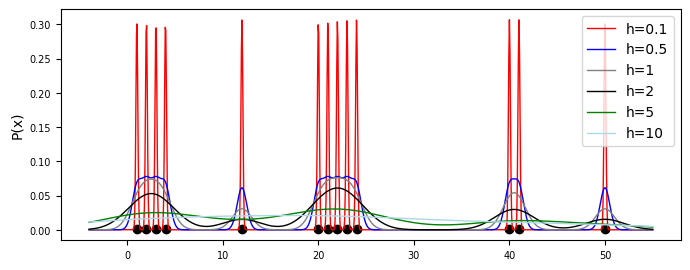

In [53]:
import numpy as np
from matplotlib.pyplot import cm

color=['red', 'blue', 'gray', 'black', 'green', 'lightblue']

N = 20
X = np.array([1, 2, 3, 4, 12, 20,21,22,23,24,40,41, 50])
X = X.reshape((len(X), 1))

X_plot = np.linspace(np.min(X)-5, np.max(X)+5, 1000)[:, np.newaxis]

plt.figure(figsize=(8,3))
plt.plot(X[:, 0], 0.001*np.ones(X.shape[0]), 'ok')
c = 0
vh = [0.1, 0.5, 1, 2, 5, 10]
for h in vh:
    kde = KernelDensity(kernel='gaussian', bandwidth=h).fit(X)
    log_dens = np.exp(kde.score_samples(X_plot)) # score_samples() returns the log density.
    plt.plot(X_plot,log_dens, color = color[c], linewidth=1, label = 'h='+str(h))
    c = c + 1
plt.ylabel('P(x)', fontsize = 10)
plt.xticks(fontsize=7)
plt.yticks(fontsize=7)
#plt.ylim((0, 0.2))
plt.legend(fontsize = 10)
plt.show(True)

Usando o método *kernel density estimation*, podemos realizar a classificação.

In [29]:
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KernelDensity
from sklearn.metrics import accuracy_score


drive.mount('/content/drive/')
data = pd.read_csv('/content/drive/My Drive/dados/Vehicle.csv', header=(0))

classes = np.array(pd.unique(data[data.columns[-1]]), dtype=str)

# Converte para matriz e vetor do numpy
data = data.to_numpy()
nrow,ncol = data.shape
y = data[:,-1]
X = data[:,0:ncol-1]

# Seleciona os conjuntos de treinamento e teste
p = 0.7 # fraction of elements in the training set
x_train, x_test, y_train, y_test = train_test_split(X, y, train_size = p, random_state = 42)

# Matriz que armazena as probabilidades para cada classe
P = pd.DataFrame(data=np.zeros((x_test.shape[0], len(classes))), columns = classes)
Pc = np.zeros(len(classes)) # Armaze a fracao de elementos em cada classe
h = 2
for i in np.arange(0, len(classes)): # Para cada classe
    elements = tuple(np.where(y_train == classes[i])) # elmentos na classe i
    Pc[i] = len(elements)/len(y_train) # Probabilidade pertencer a classe i
    Z = x_train[elements,:][0].astype(float) # Elementos no conjunto de treinamento
    kde = KernelDensity(kernel='gaussian', bandwidth=h).fit(Z)
    for j in np.arange(0,x_test.shape[0]): # para cada observacao no conjunto de teste
        x = x_test[j,:]
        x = x.reshape((1,len(x)))
        # calcula a probabilidade pertencer a cada classe
        pj = np.exp(kde.score_samples(x))
        P.loc[j,classes[i]] = pj*Pc[i]

y_pred = [] # Vetor com as classes preditas
for i in np.arange(0, x_test.shape[0]):
    c = np.argmax(np.array(P.iloc[[i]]))
    y_pred.append(classes[c])
y_pred = np.array(y_pred, dtype=str)
# calcula a acuracia
score = accuracy_score(y_pred, y_test)
print('Acuracia:', score)

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).
Acuracia: 0.6181102362204725


Notem que a acurácia depende do parâmetro $h$, conforme verficamos abaixo.

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


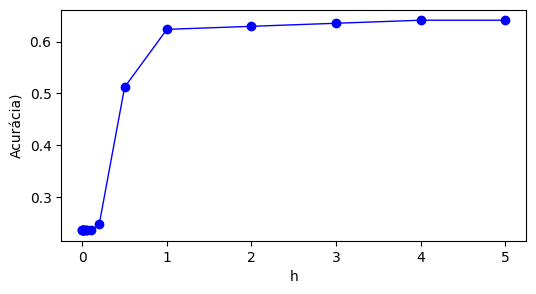

In [30]:
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from scipy.stats import multivariate_normal
from sklearn.metrics import accuracy_score


drive.mount('/content/drive/')
data = pd.read_csv('/content/drive/My Drive/dados/Vehicle.csv', header=(0))

classes = np.array(pd.unique(data[data.columns[-1]]), dtype=str)

# Converte para matriz e vetor do numpy
data = data.to_numpy()
nrow,ncol = data.shape
y = data[:,-1]
X = data[:,0:ncol-1]

# Seleciona os conjuntos de treinamento e teste
p = 0.8 # fraction of elements in the test set
x_train, x_test, y_train, y_test = train_test_split(X, y, train_size = p, random_state = 42)

####  Realiza a classificacao ####
vacc = []
vh = [0.001,0.002,0.003,0.005,0.01,0.02,0.03,0.04, 0.05, 0.1, 0.2, 0.5, 1, 2,3,4, 5]
plt.figure(figsize=(6,3))
for h in vh:
    # Matriz que armazena as probabilidades para cada classe
    P = pd.DataFrame(data=np.zeros((x_train.shape[0], len(classes))), columns = classes)
    Pc = np.zeros(len(classes)) # Armaze a fracao de elementos em cada classe
    for i in np.arange(0, len(classes)): # Para cada classe
        elements = tuple(np.where(y_train == classes[i])) # elmentos na classe i
        Pc[i] = len(elements)/len(y_train) # Probabilidade pertencer a classe i
        Z = x_train[elements,:][0].astype(float) # Elementos no conjunto de treinamento
        kde = KernelDensity(kernel='gaussian', bandwidth=h).fit(Z)
        for j in np.arange(0,x_test.shape[0]): # para cada observacao no conjunto de teste
            x = x_test[j,:]
            x = x.reshape((1,len(x)))
            # calcula a probabilidade pertencer a cada classe
            pj = np.exp(kde.score_samples(x))
            P.loc[j,classes[i]] = pj*Pc[i]

    y_pred = [] # Vetor com as classes preditas
    for i in np.arange(0, x_test.shape[0]):
        c = np.argmax(np.array(P.iloc[[i]]))
        y_pred.append(classes[c])
    y_pred = np.array(y_pred, dtype=str)
    # calcula a acuracia
    score = accuracy_score(y_pred, y_test)
    vacc.append(score)
    #print('Acuracia:', score)

plt.plot(vh,vacc, 'o-', color = 'blue', linewidth=1)
plt.xlabel('h', fontsize = 10)
plt.ylabel('Acurácia)', fontsize = 10)
plt.show(True)

---

## Naive Bayes

O Naive Bayes simplifica o problema assumindo independência entre atributos.


**A Hipótese Ingênua**

Assume:

```text
Os atributos são independentes
dada a classe
```


**Formulação**

$$
P(C|x_1,x_2,...,x_n)
\propto
P(C)
\prod_{i=1}^{n} P(x_i|C)
$$


*Intuição*

Ao invés de modelar a distribuição conjunta completa:

$$
P(x_1,x_2,...,x_n|C)
$$

o algoritmo separa em vários termos independentes.

Isso reduz drasticamente a complexidade computacional.


**Vantagens do Naive Bayes**

- extremamente rápido
- simples de implementar
- funciona bem em alta dimensão
- robusto a ruídos
- ótimo baseline


**Limitação**

A hipótese de independência raramente é totalmente verdadeira.

Mesmo assim o algoritmo funciona surpreendentemente bem.

No classificador Naive Bayes, podemos assumir que os atributos são normalmente distribuídos.

Vamos ler os dados novamente para evitar que alguma transformação anterior afete os resultados.

In [2]:
import random
random.seed(42) # define the seed (important to reproduce the results)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive

drive.mount('/content/drive/')
data = pd.read_csv('/content/drive/My Drive/dados/iris.csv', header=(0))

data = data.dropna(axis='rows') #remove NaN
# armazena os nomes das classes
classes = np.array(pd.unique(data[data.columns[-1]]), dtype=str)

print("Número de linhas e colunas na matriz de atributos:", data.shape)
attributes = list(data.columns)
data.head(10)

Mounted at /content/drive/
Número de linhas e colunas na matriz de atributos: (150, 5)


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
5,5.4,3.9,1.7,0.4,setosa
6,4.6,3.4,1.4,0.3,setosa
7,5.0,3.4,1.5,0.2,setosa
8,4.4,2.9,1.4,0.2,setosa
9,4.9,3.1,1.5,0.1,setosa


In [3]:
data = data.to_numpy()
nrow,ncol = data.shape
y = data[:,-1]
X = data[:,0:ncol-1]

Selecionando os conjuntos de treinamento e teste.

In [4]:
from sklearn.model_selection import train_test_split
p = 0.3 # fraction of elements in the test set
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size = p, random_state = 42)

Podemos realizar a classificação.

In [6]:
from sklearn.naive_bayes import GaussianNB
from sklearn import metrics

model = GaussianNB()
model.fit(x_train, y_train)

y_pred = model.predict(x_test)
print('Accuracy: ', model.score(x_test, y_test))

Accuracy:  0.9777777777777777


--- 
# Relevância para Data Science

##### Fundamento de Algoritmos

A maximização da probabilidade posterior é a base de inúmeros algoritmos modernos.


**Pipeline de Avaliação**

Os dados geralmente são divididos em:

| Conjunto | Objetivo |
|---|---|
| Treino | aprender parâmetros |
| Validação | ajustar hiperparâmetros |
| Teste | avaliar performance final |

*Intuição*

O conjunto de teste deve representar:

> dados completamente novos.


**No Free Lunch Theorem**

Não existe algoritmo universalmente melhor.

A performance depende:

- do problema
- dos dados
- da distribuição

Implicação prática, sempre precisamos:

- testar modelos
- comparar abordagens
- validar empiricamente


**Eficiência Computacional**

O Naive Bayes é extremamente eficiente.

Muitas vezes é utilizado:

- como baseline
- em sistemas de tempo real
- em NLP
- em classificação de texto


**Aplicações Reais**

*Spam Detection*

```python
Spam / Não Spam
```

*Análise de Sentimento*

```python
Positivo / Negativo
```

*Classificação Médica*

```python
Doença / Sem Doença
```

**Resumo Mental**

```text
Aprendizado supervisionado:
aprende com exemplos rotulados

Regressão:
prevê valores contínuos

Classificação:
prevê categorias

Bayes:
usa probabilidades para decidir classes

Naive Bayes:
assume independência entre atributos
para simplificar o problema
```

---

**Intuição Final**

Grande parte do Machine Learning moderno consiste em:

- modelar probabilidades
- minimizar erros
- generalizar padrões
- tomar decisões baseadas em dados

O aprendizado supervisionado é uma das bases fundamentais da Inteligência Artificial moderna.